In [3]:
import serpentTools
from serpentTools.settings import rc

rc["serpentVersion"] = "2.1.32"

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator   # ⭐ add this
from cycler import cycler

og_matlab_colors = [(0, 0, 1),(0, 1, 0),(1, 0, 0),(0, 1, 1),(1, 0, 1),(1, 1, 0),(0, 0, 0)]
plt.rcParams.update({"axes.prop_cycle": cycler(color=og_matlab_colors),"lines.linewidth": 1.5,"lines.linestyle": "-","axes.grid": False,"font.size": 12,})

import numpy as np
import math


ModuleNotFoundError: No module named 'serpentTools'

Question 1

In [12]:

det = serpentTools.read("../serpent/input_k_det0.m")

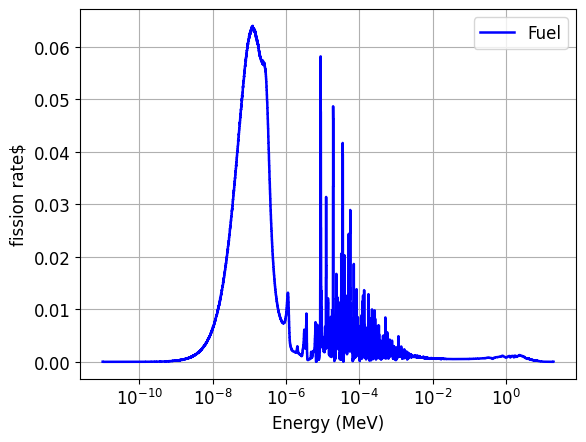

In [9]:
ff = det.detectors["dfiss_u235"]
E = ff.grids["E"]
edges = np.r_[E[:,0], E[-1,1]]

ff = ff.tallies.ravel()

plt.step(edges, np.r_[ff[0], ff], where="post", lw=1.8, label="Fuel")


plt.xscale("log")
# plt.yscale("log")  # optional

plt.xlabel("Energy (MeV)")
plt.ylabel(r"fission rate$")

plt.legend()
plt.grid(True, which="both")

plt.show()

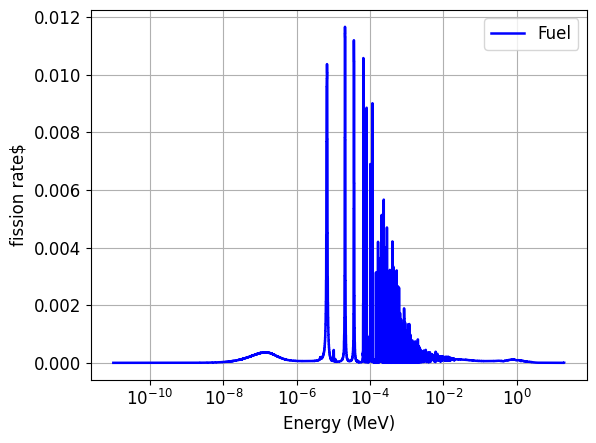

In [18]:
d238 = det.detectors["dabs_u238"]
E = d238.grids["E"]
edges = np.r_[E[:,0], E[-1,1]]

d238 = d238.tallies.ravel()

plt.step(edges, np.r_[d238[0], d238], where="post", lw=1.8, label="Fuel")


plt.xscale("log")
# plt.yscale("log")  # optional

plt.xlabel("Energy (MeV)")
plt.ylabel(r"fission rate$")

plt.legend()
plt.grid(True, which="both")

plt.show()

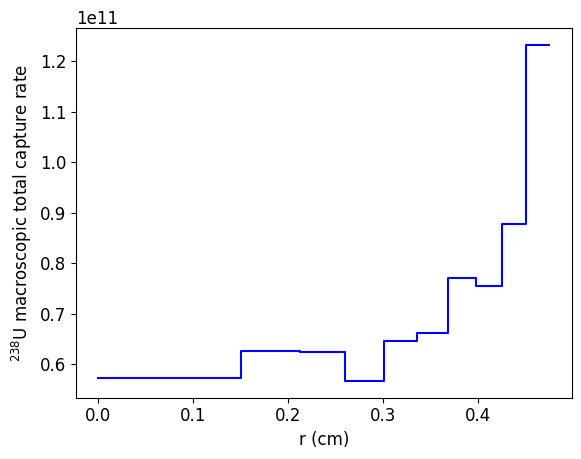

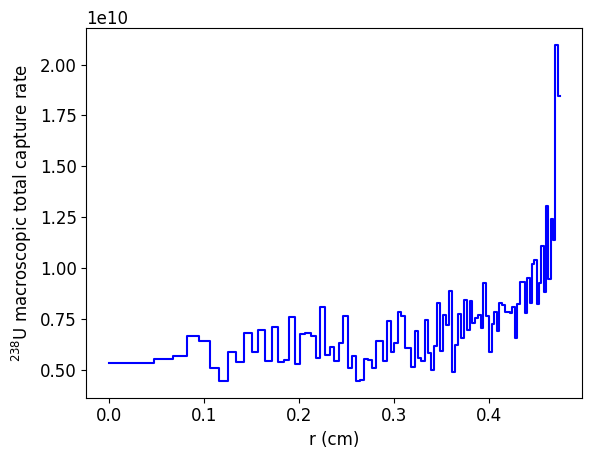

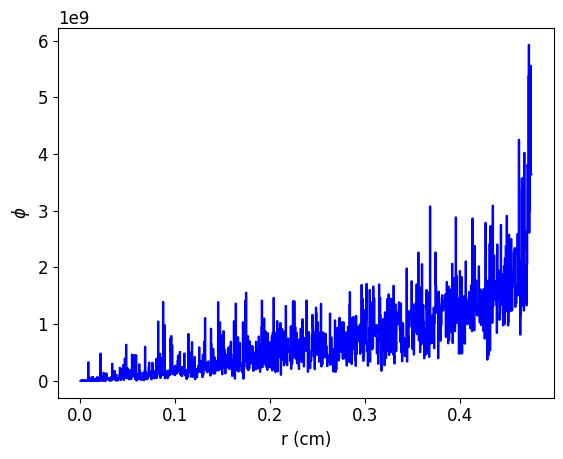

In [39]:
# print(" ".join(f"{x:.6f}" for x in 0.475*np.sqrt(np.arange(101)/100)))

U = det.detectors["U238_cap_10"]
R = U.grids["R"]              
y = U.tallies[:, 0] if U.tallies.ndim > 1 else U.tallies

edges = np.r_[R[:, 0], R[-1, 1]]   
y_step = np.r_[y, y[-1]]           

plt.step(edges, y_step, where="post")
plt.xlabel("r (cm)")
plt.ylabel(r"$^{238}\mathrm{U}$ macroscopic total capture rate")
plt.show()

U = det.detectors["U238_cap_100"]
R = U.grids["R"]              
y = U.tallies[:, 0] if U.tallies.ndim > 1 else U.tallies

edges = np.r_[R[:, 0], R[-1, 1]]   
y_step = np.r_[y, y[-1]]           

plt.step(edges, y_step, where="post")
plt.xlabel("r (cm)")
plt.ylabel(r"$^{238}\mathrm{U}$ macroscopic total capture rate")
plt.show()

PHI = det.detectors["radial_flux"]
R   = PHI.grids["R"]

phi = PHI.tallies[:, 0] if PHI.tallies.ndim > 1 else PHI.tallies

edges  = np.r_[R[:, 0], R[-1, 1]]
phi_st = np.r_[phi, phi[-1]]

plt.step(edges, phi_st, where="post")
plt.xlabel("r (cm)")
plt.ylabel(r"$\phi$")  
plt.show()

Question 2

In [40]:

det = serpentTools.read("q2/input_det0.m")

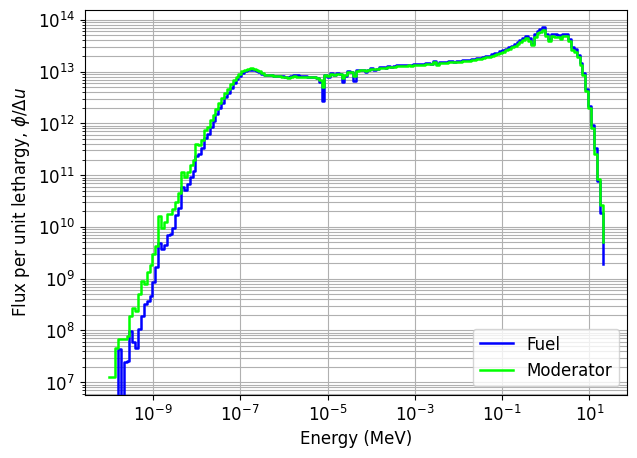

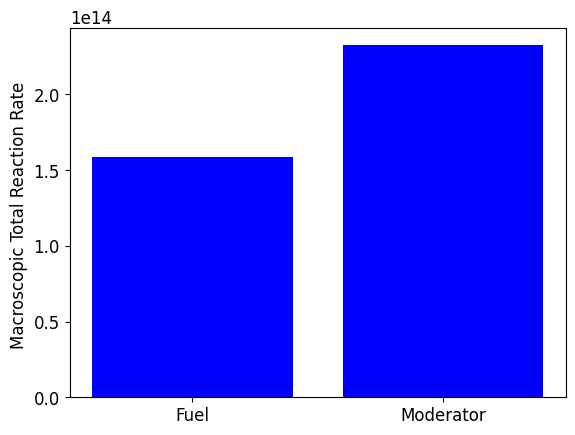

In [41]:
plt.figure(figsize=(7,5))

ff = det.detectors["fuel_flux"]
mf = det.detectors["mod_flux"]

E = ff.grids["E"]
edges = np.r_[E[:,0], E[-1,1]]

phi_ff = ff.tallies.ravel()
phi_mf = mf.tallies.ravel()

plt.step(edges, np.r_[phi_ff[0], phi_ff], where="post", lw=1.8, label="Fuel")
plt.step(edges, np.r_[phi_mf[0], phi_mf], where="post", lw=1.8, label="Moderator")

plt.xscale("log")
plt.yscale("log")  # optional

plt.xlabel("Energy (MeV)")
plt.ylabel(r"Flux per unit lethargy, $\phi/\Delta u$")

plt.legend()
plt.grid(True, which="both")

plt.show()

fuel_rr = det.detectors["fuel_macro_rr"].tallies.ravel()
mod_rr = det.detectors["mod_macro_rr"].tallies.ravel()

regions = ["Fuel", "Moderator"]
values  = [fuel_rr[0] , mod_rr[0]]

# print( mod_rr[0]/fuel_rr[0])

plt.bar(regions, values)
plt.ylabel("Macroscopic Total Reaction Rate ")
plt.show()

Question 3


In [42]:
det1200k = serpentTools.read("q3/1200k_det0.m")
det600k = serpentTools.read("q3/600k_det0.m")

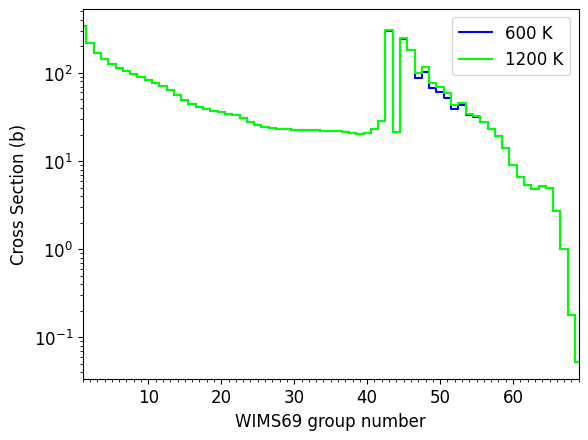

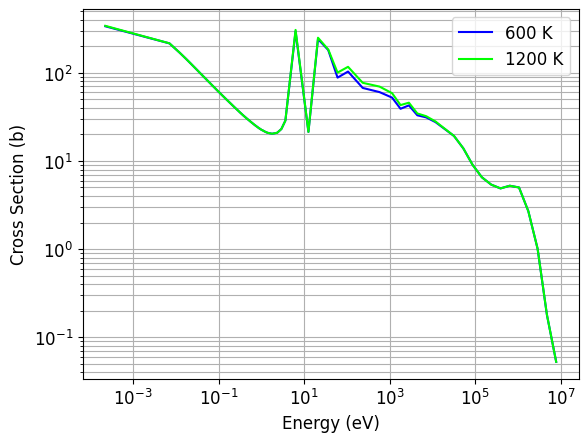

In [43]:
cap1200k = det1200k.detectors["238U_cap"]
cap600k  = det600k.detectors["238U_cap"]

phi1200k = det1200k.detectors["group_flux"]
phi600k  = det600k.detectors["group_flux"]

E = cap1200k.grids["E"]
E_low, E_high = E[:, 0], E[:, 1]
G = len(E_low)

RR1200 = cap1200k.tallies.flatten()
FL1200 = phi1200k.tallies.flatten()
RR600  = cap600k.tallies.flatten()
FL600  = phi600k.tallies.flatten()

NA   = 6.02214076e23
M235 = 235.0439299
M238 = 238.0507884
MO   = 15.999

rho_uo2 = 10.4
enr = 0.035

MU   = enr*M235 + (1-enr)*M238
MUO2 = MU + 2*MO

N_U  = (rho_uo2 / MUO2) * NA
N238 = (1-enr) * N_U

Sigma_c_1200 = RR1200 / FL1200
Sigma_c_600  = RR600  / FL600

sigma_c_1200_b = (Sigma_c_1200 / N238) / 1e-24
sigma_c_600_b  = (Sigma_c_600  / N238) / 1e-24

groups = np.arange(1, G + 1)

plt.step(groups, sigma_c_600_b,  where="mid", label="600 K")
plt.step(groups, sigma_c_1200_b, where="mid", label="1200 K")

plt.xlabel("WIMS69 group number")
plt.ylabel(r"Cross Section (b)")
plt.xlim(1, G)
plt.yscale("log")

ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(1))

plt.grid(False, which="major")
plt.legend()
plt.show()

E_mid = np.sqrt(E_low * E_high)

E_mid_eV = E_mid * 1e6

sigma_c_600_b_plot  = np.where(sigma_c_600_b  > 0, sigma_c_600_b,  np.nan)
sigma_c_1200_b_plot = np.where(sigma_c_1200_b > 0, sigma_c_1200_b, np.nan)

plt.plot(E_mid_eV, sigma_c_600_b_plot,  label="600 K")
plt.plot(E_mid_eV, sigma_c_1200_b_plot, label="1200 K")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy (eV)")
plt.ylabel(r"Cross Section (b)")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [44]:
detsingle = serpentTools.read("q3/single238_det0.m")
detdouble = serpentTools.read("q3/double238_det0.m")

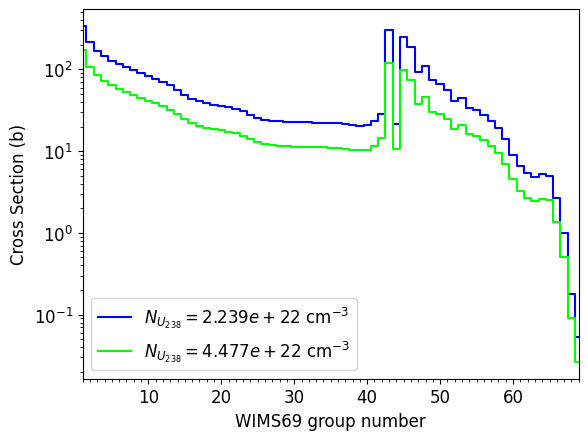

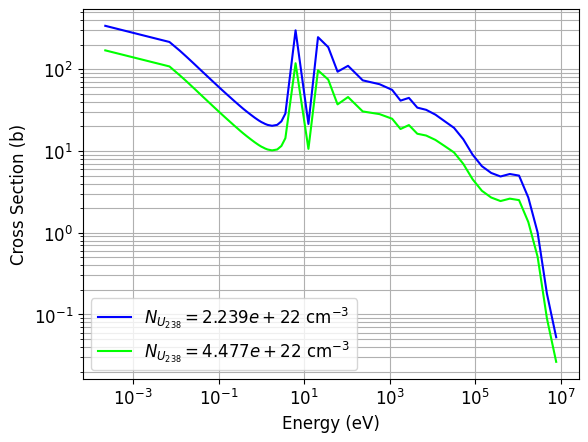

In [45]:

cap_single = detsingle.detectors["238U_cap"]
phi_single = detsingle.detectors["group_flux"]

cap_double = detdouble.detectors["238U_cap"]
phi_double = detdouble.detectors["group_flux"]

E = cap_single.grids["E"]
E_low, E_high = E[:, 0], E[:, 1]
G = len(E_low)
groups = np.arange(1, G + 1)

RR_single = cap_single.tallies.flatten()
FL_single = phi_single.tallies.flatten()

RR_double = cap_double.tallies.flatten()
FL_double = phi_double.tallies.flatten()


NA   = 6.02214076e23
M235 = 235.0439299
M238 = 238.0507884
MO   = 15.999

rho_uo2_single = 10.4
enr_single = 0.035

MU_single   = enr_single*M235 + (1-enr_single)*M238
MUO2_single = MU_single + 2*MO
N_U_single  = (rho_uo2_single / MUO2_single) * NA
N238_single = (1-enr_single) * N_U_single

Sigma_c_single = RR_single / FL_single
sigma_c_single_b = (Sigma_c_single / N238_single) / 1e-24


rho_uo2_double = 20.436
enr_double = 0.01781

MU_double   = enr_double*M235 + (1-enr_double)*M238
MUO2_double = MU_double + 2*MO
N_U_double  = (rho_uo2_double / MUO2_double) * NA
N238_double = (1-enr_double) * N_U_double

Sigma_c_double = RR_double / FL_double
sigma_c_double_b = (Sigma_c_double / N238_double) / 1e-24

plt.step(groups, sigma_c_single_b, where="mid", label=rf"$N_{{U_{{238}}}} = {N238_single:.3e}\ \mathrm{{cm^{{-3}}}}$")
plt.step(groups, sigma_c_double_b, where="mid", label=rf"$N_{{U_{{238}}}} = {N238_double:.3e}\ \mathrm{{cm^{{-3}}}}$")

plt.xlabel("WIMS69 group number")
plt.ylabel("Cross Section (b)")
plt.xlim(1, G)
plt.yscale("log")

ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(1))

plt.grid(False, which="major")
plt.legend()
plt.show()

E_mid = np.sqrt(E_low * E_high)
E_mid_eV = E_mid * 1e6

sigma_c_single_b_plot = np.where(sigma_c_single_b > 0, sigma_c_single_b, np.nan)
sigma_c_double_b_plot = np.where(sigma_c_double_b > 0, sigma_c_double_b, np.nan)

plt.plot(E_mid_eV, sigma_c_single_b_plot, label=rf"$N_{{U_{{238}}}} = {N238_single:.3e}\ \mathrm{{cm^{{-3}}}}$")
plt.plot(E_mid_eV, sigma_c_double_b_plot, label=rf"$N_{{U_{{238}}}} = {N238_double:.3e}\ \mathrm{{cm^{{-3}}}}$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Cross Section (b)")
plt.grid(True, which="both")
plt.legend()
plt.show()

Question 4

In [46]:
res_baseline = serpentTools.read("q4/baseline_res.m")
res_boron   = serpentTools.read("q4/boron_res.m")
res_fuel    = serpentTools.read("q4/fuel_res.m")
res_mod     = serpentTools.read("q4/mod_res.m")


cases = {
    "Boron":  (res_boron, 50.0,  "ppm"),  
    "Fuel T": (res_fuel,  50.0,  "K"),
    "Mod T":  (res_mod,   5.0,   "K"),
}

mu1, rel1 = res_baseline.resdata["impKeff"][:2]
sigma1 = rel1 * mu1
var1 = sigma1**2

print("Baseline:")
print(f"  k_eff = {mu1:.6f} ± {sigma1:.6f}\n")

for name, (res, delta_x, unit) in cases.items():
    C = 1e5 / float(delta_x) 

    mu2, rel2 = res.resdata["impKeff"][:2]
    sigma2 = rel2 * mu2
    var2 = sigma2**2

    mean_y = C * (1/mu1 - 1/mu2) + C * (var1/mu1**3 - var2/mu2**3)

    var_y = (
        C**2 * (var1/mu1**4 + var2/mu2**4)
        + 2*C**2 * (var1**2/mu1**6 + var2**2/mu2**6)
    )

    print(f"{name:10s} (Δx = {delta_x:g} {unit}):")
    print(f"  k_eff  = {mu2:.6f} ± {sigma2:.6f}")
    print(f"  y_mean = {mean_y:.3f} pcm/{unit}")
    print(f"  σ_y    = {math.sqrt(var_y):.3f} pcm/{unit}\n")

Baseline:
  k_eff = 1.180340 ± 0.000484

Boron      (Δx = 50 ppm):
  k_eff  = 1.177190 ± 0.000447
  y_mean = -4.534 pcm/ppm
  σ_y    = 0.948 pcm/ppm

Fuel T     (Δx = 50 K):
  k_eff  = 1.176740 ± 0.000447
  y_mean = -5.184 pcm/K
  σ_y    = 0.949 pcm/K

Mod T      (Δx = 5 K):
  k_eff  = 1.171780 ± 0.000457
  y_mean = -123.780 pcm/K
  σ_y    = 9.621 pcm/K



Question 5

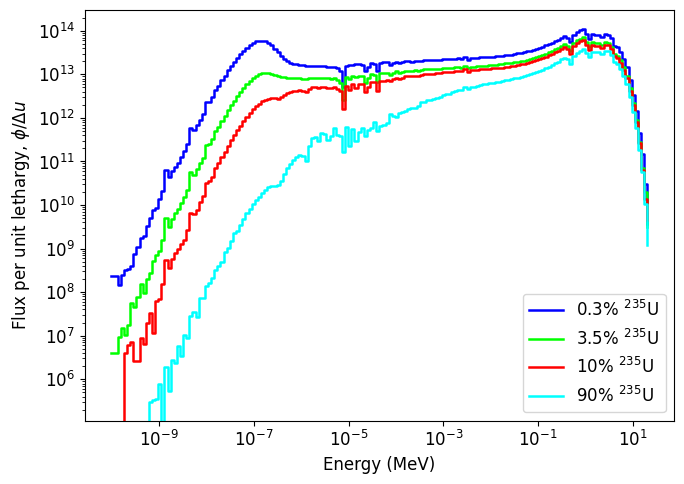

In [47]:
files = [
    ("q5/0_3_det0.m", "0.3% ${}^{235}\mathrm{U}$"),
    ("q5/3_5_det0.m", "3.5% ${}^{235}\mathrm{U}$"),
    ("q5/10_det0.m",  "10% ${}^{235}\mathrm{U}$"),
    ("q5/90_det0.m",  "90% ${}^{235}\mathrm{U}$"),
]


plt.figure(figsize=(7,5))

for fname, label in files:
    detfile = serpentTools.read(fname)
    ff = detfile.detectors["fuel_flux"]

    E = ff.grids["E"]
    edges = np.r_[E[:, 0], E[-1, 1]]

    phi = ff.tallies.ravel()

    plt.step(
        edges,
        np.r_[phi[0], phi],
        where="post",
        lw=1.8,
        label=label
    )

plt.xscale("log")
plt.yscale("log")  # optional but standard for spectra

plt.xlabel("Energy (MeV)")
plt.ylabel(r"Flux per unit lethargy, $\phi/\Delta u$")

plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

d10 = serpentTools.read("q5/10_det0.m").detectors["fuel_flux"].tallies.ravel()
d90 = serpentTools.read("q5/90_det0.m").detectors["fuel_flux"].tallies.ravel()


Question 6

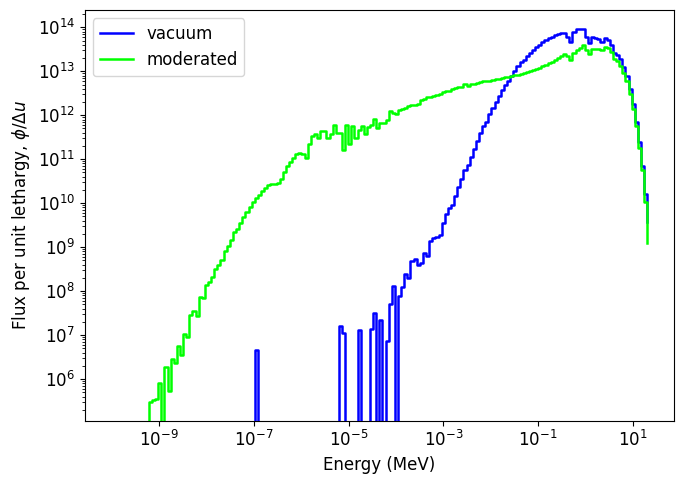

In [48]:
files = [
    ("q6/90v_det0.m",  "vacuum"),
    ("q5/90_det0.m",  "moderated"),
]


plt.figure(figsize=(7,5))

for fname, label in files:
    detfile = serpentTools.read(fname)
    ff = detfile.detectors["fuel_flux"]

    E = ff.grids["E"]
    edges = np.r_[E[:, 0], E[-1, 1]]

    phi = ff.tallies.ravel()

    plt.step(
        edges,
        np.r_[phi[0], phi],
        where="post",
        lw=1.8,
        label=label
    )

plt.xscale("log")
plt.yscale("log")  # optional but standard for spectra

plt.xlabel("Energy (MeV)")
plt.ylabel(r"Flux per unit lethargy, $\phi/\Delta u$")

plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

d10 = serpentTools.read("q5/10_det0.m").detectors["fuel_flux"].tallies.ravel()
d90 = serpentTools.read("q5/90_det0.m").detectors["fuel_flux"].tallies.ravel()


Question 7

In [49]:
res_baseline = serpentTools.read("q7/baseline_res.m")
res_boron   = serpentTools.read("q7/boron_res.m")
res_fuel    = serpentTools.read("q7/fuel_res.m")
res_mod     = serpentTools.read("q7/mod_res.m")


cases = {
    "Boron":  (res_boron, 50.0,  "ppm"),  
    "Fuel T": (res_fuel,  50.0,  "K"),
    "Mod T":  (res_mod,   5.0,   "K"),
}

mu1, rel1 = res_baseline.resdata["impKeff"][:2]
sigma1 = rel1 * mu1
var1 = sigma1**2

print("Baseline:")
print(f"  k_eff = {mu1:.6f} ± {sigma1:.6f}\n")

for name, (res, delta_x, unit) in cases.items():
    C = 1e5 / float(delta_x) 

    mu2, rel2 = res.resdata["impKeff"][:2]
    sigma2 = rel2 * mu2
    var2 = sigma2**2

    mean_y = C * (1/mu1 - 1/mu2) + C * (var1/mu1**3 - var2/mu2**3)

    var_y = (
        C**2 * (var1/mu1**4 + var2/mu2**4)
        + 2*C**2 * (var1**2/mu1**6 + var2**2/mu2**6)
    )

    print(f"{name:10s} (Δx = {delta_x:g} {unit}):")
    print(f"  k_eff  = {mu2:.6f} ± {sigma2:.6f}")
    print(f"  y_mean = {mean_y:.3f} pcm/{unit}")
    print(f"  σ_y    = {math.sqrt(var_y):.3f} pcm/{unit}\n")

Baseline:
  k_eff = 1.844130 ± 0.000258

Boron      (Δx = 50 ppm):
  k_eff  = 1.843600 ± 0.000258
  y_mean = -0.312 pcm/ppm
  σ_y    = 0.215 pcm/ppm

Fuel T     (Δx = 50 K):
  k_eff  = 1.843270 ± 0.000258
  y_mean = -0.506 pcm/K
  σ_y    = 0.215 pcm/K

Mod T      (Δx = 5 K):
  k_eff  = 1.846300 ± 0.000258
  y_mean = 12.747 pcm/K
  σ_y    = 2.146 pcm/K

